# Анализ датасета

In [49]:
import json

def load_json(path):
    with open(path, 'r', encoding='utf8') as file:
        return json.load(file)

In [50]:
data = load_json("all_texts.json")

Анализ тестовых данных

In [51]:
lens = [len(x['text'].split()) for x in data]

max_l, min_l, mean_l = max(lens), min(lens), sum(lens)/len(lens)

print(f'Минимальная длина текста: {min_l}')
print(f'Максимальная длина текста: {max_l}')
print(f'Средняя длина текста: {mean_l:.3f}')

Минимальная длина текста: 5
Максимальная длина текста: 107
Средняя длина текста: 26.801


<BarContainer object of 55 artists>

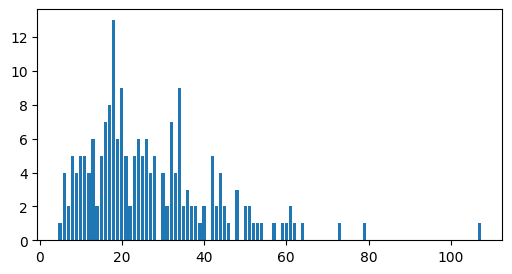

In [52]:
from collections import Counter
from matplotlib import pyplot as plt

len_counts = Counter(lens)
plt.figure(figsize = (6,3))
plt.bar(len_counts.keys(), len_counts.values())

Вывод самого длинного текста.

In [53]:
for elem in data:
    if len(elem['text'].split()) == max_l:
        print(elem['sent_id'])
        print(elem['text'])

39
A project you might reasonably have assumed was a jokey one-off on the part of a Britpop star has instead lasted a quarter of a century, long enough for Damon Albarn and Jamie Hewlett’s concept of a “virtual group” to seem less like a snarky gag at the expense of manufactured pop than oddly commonplace: their latest release is launched into a world where cartoon K-pop bands Huntr/x and Saja Boys have collectively spent 100 weeks and counting on the UK singles chart, where the anime “vocaloid” Hatsune Miku is playing the O2 Arena and where celebrated producer Timbaland has launched an AI-generated singer called Tata Taktumi.


Определение количества текстов, состоящих более чем из одного предложения.

In [54]:
count = 0
for elem in data:
    text = elem['text']
    if '\n' in text or '.' in text[:-1]:
        count+=1
print(count)

35


Преобразование наших данных в датафрейм.

In [55]:
opinions = []
for elem in data:
    for op in elem['opinions']:
        # источник и интервал
        if len(op['Source'][0]) > 1:
            source_text = op['Source'][0]
            source_span = op['Source'][1]
        else:
            source_text = op['Source'][0][0]
            source_span = op['Source'][1][0]
        # объект и интервал
        if len(op['Target'][0]) > 1:
            target_text = op['Target'][0]
            target_span = op['Target'][1]
        else:
            target_text = op['Target'][0][0]
            target_span = op['Target'][1][0]
        # выражение и интервал
        if len(op['Polar_expression'][0]) > 1:
            exp_text = op['Polar_expression'][0]
            exp_span = op['Polar_expression'][1]
        else:
            exp_text = op['Polar_expression'][0][0]
            exp_span = op['Polar_expression'][1][0]
        opinions.append([elem['sent_id'], elem['text'], source_text, target_text, exp_text,
                       op['Polarity'], source_span, target_span, exp_span])

In [56]:
import pandas as pd
cols = ['sent_id', 'text', 'Source', 'Target', 'Polar_expression', 'Polarity', 'Source_span', 'Target_span', 'Polar_expression_span']
df = pd.DataFrame(opinions, columns = cols)
df

,sent_id,text,Source,Target,Polar_expression,Polarity,Source_span,Target_span,Polar_expression_span
0,1,"These days, a doomsday bunker (or, in Elon Mus...",any self-respecting billionaire,a doomsday bunker,is de rigueur,POS,98:129,12:29,80:93
1,2,A slew of recent dramas suggests that we are f...,we,underground real estate,are fascinated by such impressive,POS,38:40,75:98,41:74
2,3,"Most audacious is Paradise on Disney+, in whic...",AUTHOR,Paradise on Disney+,Most audacious is,POS,NULL,18:37,0:17
3,3,"Most audacious is Paradise on Disney+, in whic...",AUTHOR,building project,staggeringly elaborate,POS,NULL,134:150,111:133
4,4,On the surface at least – no pun intended – it...,NULL,Fallout,hugely popular,POS,0:0,126:133,96:110
...,...,...,...,...,...,...,...,...,...
180,191,"Instead, much of that momentum is being crowde...",AUTHOR,"a worsening affordability crisis, geopolitical...",anxieties,NEG,NULL,79:207,68:77
181,192,For the tech CEOs leading the AI race and enri...,the tech CEOs leading,AI,a glimmering unicorn,POS,4:25,30:32,125:145
182,194,"For the rest of us, it's hard to feel confiden...",AUTHOR,remarks,hard to feel confident,NEG,NULL,65:72,25:47
183,194,"For the rest of us, it's hard to feel confiden...",AUTHOR,remarks,offhand,NEG,NULL,65:72,57:64


Оценка распределения классов тональности.

Polarity
NEG    95
POS    90
Name: count, dtype: int64


<Axes: xlabel='Polarity'>

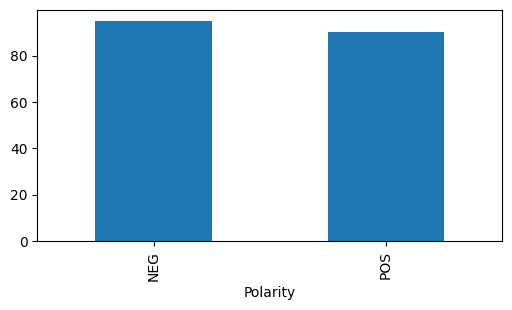

In [57]:
print(df['Polarity'].value_counts())

plt.figure(figsize = (6,3))
df['Polarity'].value_counts().plot.bar()

Тексты с множественными мнениями: распределение на графике.

In [58]:
textcount = Counter(df['text'].value_counts())
textcount

Counter({5: 1, 4: 2, 3: 6, 2: 40, 1: 74})

<BarContainer object of 5 artists>

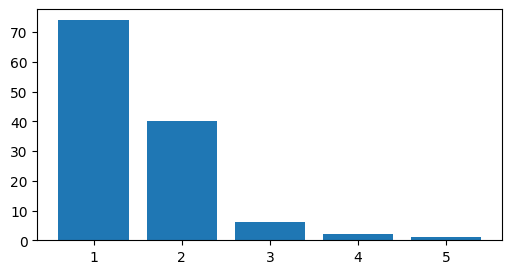

In [59]:
plt.figure(figsize = (6,3))
plt.bar(textcount.keys(), textcount.values())

Подсчёт максимальной и средней длины для источника, объекта и выражения (с примерами)

In [60]:
sources = []
for item in df['Source']:
    if isinstance(item, str):
        sources.append(item)
    else:
        sources+=item
max_s = max([len(x.split()) for x in sources])
mean_s = sum([len(x.split()) for x in sources])/len(sources)
print(f'Максимальная длина источника: {max_s}')
print(f'Средняя длина источника: {mean_s:.3f}')

print(f'Самый длинный источник:')
for item in df['Source']:
    if isinstance(item, str) and len(item.split()) == max_s:
        print(f'"{item}"')

Максимальная длина источника: 7
Средняя длина источника: 1.357
Самый длинный источник:
"Damon Albarn and Jamie Hewlett’s cartoon band"


In [61]:
targets = []
for item in df['Target']:
    if isinstance(item, str):
        targets.append(item)
    else:
        targets+=item
max_t = max([len(x.split()) for x in targets])
mean_t = sum([len(x.split()) for x in targets])/len(targets)
print(f'Максимальная длина объекта: {max_t}')
print(f'Средняя длина объекта: {mean_t:.3f}')

for item in df['Target']:
    if isinstance(item, str) and len(item.split()) == max_t:
        print(f'Самый длинный объект:\n"{item}"')

Максимальная длина объекта: 34
Средняя длина объекта: 4.120
Самый длинный объект:
"As people tried to pass by, they glanced down, saw the hole and panicked, feeling that they were falling, so dropping to the ground, even though of course the pavement was flat and solid"
Самый длинный объект:
"As people tried to pass by, they glanced down, saw the hole and panicked, feeling that they were falling, so dropping to the ground, even though of course the pavement was flat and solid"


In [62]:
expressions = list()
for item in df['Polar_expression']:
    if isinstance(item, str):
        expressions.append(item)
    else:
        expressions+=item
max_e = max([len(x.split()) for x in expressions])
mean_e = sum([len(x.split()) for x in expressions])/len(expressions)
print(f'Максимальная длина выражения: {max_e}')
print(f'Средняя длина выражения: {mean_e:.3f}')

for item in df['Polar_expression']:
    if isinstance(item, str) and len(item.split()) == max_e:
        print(f'Самое длинное выражение:\n"{item}"')

Максимальная длина выражения: 48
Средняя длина выражения: 4.790
Самое длинное выражение:
"more consistent – more like an album, less like a playlist constructed by someone with impressively wide-ranging taste – than its immediate predecessors: something you’re more likely to listen to from start to finish than play with your finger ready to click fast-forward, panning for the best bits"


Самые частые источники

In [63]:
df['Source'].value_counts()

,count
Source,
AUTHOR,110
NULL,9
Woolfson,4
Krys Marshall,3
he,3
she,2
Howey,2
The Happy Dictator,2
they,2


Количество разрывных и множественных источников, объектов и выражений (с примерами)

In [64]:
s, t, e = 0, 0, 0
for i, row in df.iterrows():
    if isinstance(row['Source'], list):
        s+=1
    if isinstance(row['Target'], list):
        t+=1
    if isinstance(row['Polar_expression'], list):
        e+=1

print(f'Множественный/ фрагментированный источник: {s}')
print(f'Множественный/ фрагментированный объект: {t}')
print(f'Множественное/ фрагментированное выражение: {e}')

Множественный/ фрагментированный источник: 0
Множественный/ фрагментированный объект: 4
Множественное/ фрагментированное выражение: 21


In [65]:
for i, row in df.iterrows():
    if isinstance(row['Polar_expression'], list):
        print(row['Polar_expression'], row['Polar_expression_span'], sep = '\n')

['turns out to be based on deception', 'It’s an illusion, and it’s not even giving us what it promised.']
['59:93', '187:250']
['The most terrifying character in Paradise', 'ruthless']
['0:41', '123:131']
['He started crying', 'He was physically walking up this thing that he had imagined years earlier']
['84:101', '124:198']
['career peak', 'glowing with life']
['39:50', '73:90']
['seldom concise affairs', 'of variable quality', 'tricky to navigate']
['20:42', '51:70', '77:95']
['wistful, descending melodies', 'liberally decorated']
['72:100', '106:125']
['trying a bit too hard to put a positive spin on things', 'gratingly perky tune being whistled']
['32:86', '203:238']
['big footprint', 'the biggest sitcom on Earth']
['19:31', '86:112']
['blame', 'for social ills']
['10:15', '50:65']
['great strengths', 'readiness to blame people']
['11:26', '92:117']
['hate', 'want to reverse']
['115:119', '125:140']
['might not expect', 'huge appeal', 'Yet it does']
['21:37', '95:106', '286:297']
[

# Применение больших языковых моделей

## Фью-шот с подбором примеров в зависимости от тематики статьи

In [66]:
def load_json(path):
    with open(path, 'r', encoding='utf8') as f:
        return json.load(f)


def get_single_value(field):
    if not field or not field[0]:
        return "NULL"
    return field[0][0]


def format_example(entry):
    lines = []
    lines.append("***Text***")
    lines.append(entry["text"])
    lines.append("***Answer***")
    for op in entry.get("opinions", []):
        source = get_single_value(op["Source"])
        target = get_single_value(op["Target"])
        polarity = op["Polarity"]
        polar_expression = get_single_value(op["Polar_expression"])

        lines.append(
            f'Source: "{source}", Target: "{target}", Polarity: "{polarity}", '
            f'Polar_expression: "{polar_expression}".'
        )

    return "\n".join(lines)


categories = ["culture", "science", "politics"]

raw_data_dict = {
    category: load_json(f"{category}_ex.json")
    for category in categories
}

# raw_data_dict = {"culture": load_json(f"{"culture"}_ex.json")}

data_dict = {
    category: [format_example(entry) for entry in entries]
    for category, entries in raw_data_dict.items()
}

In [67]:
print(data_dict["culture"][0])

***Text***
In these shows, though, the deadliest threat invariably comes from within the bunker – sometimes even from within the “nuclear” family at its heart.
***Answer***
Source: "AUTHOR", Target: "the bunker", Polarity: "NEG", Polar_expression: "the deadliest threat invariably comes from within".


In [68]:
BASE_PROMPT = (
    "Your task is to analyze a text and extract opinion expressions as opinion tuples. "
    "Each opinion tuple must contain 4 components:\n"
    "1. Source of the opinion: the author, a named entity from the text (a substring of the original text), or \"NULL\". Key = Source;\n"
    "2. Target of the opinion: a named entity from the text (a substring of the original text). Key = Target;\n"
    "3. Polarity: positive or negative (\"POS\" / \"NEG\"). Only \"POS\" and \"NEG\" are allowed; \"NULL\" is not allowed. Key = Polarity;\n"
    "4. Polar expression: the argument on which the final polarity is based "
    "(one or more substrings of the original text). Key = Polar_expression;\n"
    "The values of Source, Target, and Polarity must be enclosed in quotation marks. "
    "If the opinion source is absent, set Source = \"NULL\". If the source is the author, set Source = \"AUTHOR\". "
    "IMPORTANT:"
    "All Source, Target, and Polar_expression MUST be exact substrings of the input text."
    "If a phrase does not appear exactly in the text, DO NOT include it."
    "DO NOT use any information from previous examples."
    "ONLY extract information from the given text."
    "If no valid opinion tuples can be extracted, return an empty list []."
    "Target and Polar_expression must always exactly match substrings of the text and keep the same grammatical form.\n"
    "Do not add any explanations. Return the answer as a JSON list, where each element is an opinion tuple. "
    "Do not output the word json. "
    "Each opinion tuple is a dictionary with four keys: Source, Target, Polarity, Polar_expression.\n"
    "For the extracted Source, Target, Polarity, and Polar_expression, the following statement must be true: "
    "based on Polar_expression, Source has a Polarity relation to Target.\n"
)

In [69]:
def build_prompt(text, topic, data_dict, n_examples):
    """
    Дополняет промпт нужными примерами, основываясь на data_dict[topic].
    """
    if topic not in data_dict:
        raise KeyError(f"Unknown topic: {topic}. Available topics: {list(data_dict.keys())}")

    examples = data_dict[topic][:n_examples]

    examples_block = "\n\n".join(examples)

    final_prompt = (
        BASE_PROMPT
        + "\n\n"
        + "Below are examples of the task:\n"
        + examples_block
        + "\n\n"
        + "Analyze the following text in the same way.\n"
        + "***Text***\n"
        + text
        + "\n***Answer***\n"
    )
    return final_prompt

### Модель Qwen2.5-7B-Instruct

In [30]:
!pip install transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.0 MB/s eta 0:00:00


In [31]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_name = "Qwen/Qwen2.5-7B-Instruct"

# Конфигурация 4‑битной квантизации
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quant_config,
    device_map="auto",
    trust_remote_code=True
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

#### Фью-шот на 5 примерах

In [70]:
# пример
prompt = build_prompt(
    text="In these shows, though, the deadliest threat invariably comes from within the bunker – sometimes even from within the “nuclear” family at its heart.",
    topic="culture",
    data_dict=data_dict,
    n_examples=5
)

print(prompt)

Your task is to analyze a text and extract opinion expressions as opinion tuples. Each opinion tuple must contain 4 components:
1. Source of the opinion: the author, a named entity from the text (a substring of the original text), or "NULL". Key = Source;
2. Target of the opinion: a named entity from the text (a substring of the original text). Key = Target;
3. Polarity: positive or negative ("POS" / "NEG"). Only "POS" and "NEG" are allowed; "NULL" is not allowed. Key = Polarity;
4. Polar expression: the argument on which the final polarity is based (one or more substrings of the original text). Key = Polar_expression;
The values of Source, Target, and Polarity must be enclosed in quotation marks. If the opinion source is absent, set Source = "NULL". If the source is the author, set Source = "AUTHOR". IMPORTANT:All Source, Target, and Polar_expression MUST be exact substrings of the input text.If a phrase does not appear exactly in the text, DO NOT include it.DO NOT use any information

In [71]:
def inference(prompt_text):
    messages = [
        {"role": "system", "content": "You are a JSON-only assistant. Your entire response must be a single JSON array, nothing else. You can only extract opinions from a given text. Everything else is strictly prohibited."},
        {"role": "user", "content": prompt_text}
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=512
    )
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]
    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return response.strip()

Применение функции к одному предложению

In [72]:
sent_id = 0
text = data[sent_id]["text"]

prompt = build_prompt(
    text,
    topic=data[sent_id]["tag"],
    data_dict=data_dict,
    n_examples=5
)

print(f'Prompt:\n{prompt}\n{text}\n')
output = inference(data[sent_id]["text"])
print(f'Predicted tuple: {type(output)}\n{output}\n')
print(f'Gold tuple: {type(data[sent_id]["opinions"])}\n{data[sent_id]["opinions"]}')

Prompt:
Your task is to analyze a text and extract opinion expressions as opinion tuples. Each opinion tuple must contain 4 components:
1. Source of the opinion: the author, a named entity from the text (a substring of the original text), or "NULL". Key = Source;
2. Target of the opinion: a named entity from the text (a substring of the original text). Key = Target;
3. Polarity: positive or negative ("POS" / "NEG"). Only "POS" and "NEG" are allowed; "NULL" is not allowed. Key = Polarity;
4. Polar expression: the argument on which the final polarity is based (one or more substrings of the original text). Key = Polar_expression;
The values of Source, Target, and Polarity must be enclosed in quotation marks. If the opinion source is absent, set Source = "NULL". If the source is the author, set Source = "AUTHOR". IMPORTANT:All Source, Target, and Polar_expression MUST be exact substrings of the input text.If a phrase does not appear exactly in the text, DO NOT include it.DO NOT use any inf

Тестирование на датасете

In [73]:
from tqdm.auto import tqdm

train_output = []
progress_bar = tqdm(range(len(data)))

for sample in data:
    prompt = build_prompt(
        sample["text"],
        topic=sample["tag"],
        data_dict=data_dict,
        n_examples=5
    )
    sample_output = inference(prompt)   # новая функция
    train_output.append(sample_output)
    progress_bar.update(1)

  0%|          | 0/196 [00:00<?, ?it/s]

In [74]:
print(train_output[:10])

['[{"Source": "NULL", "Target": "Peter Thiel\'s", "Polarity": "POS", "Polar_expression": "described as \\"mega\\""}, {"Source": "NULL", "Target": "Peter Thiel\'s", "Polarity": "NEG", "Polar_expression": "located in New Zealand"}]', '[{"Source": "NULL", "Target": "doomsday bunker", "Polarity": "POS", "Polar_expression": "de rigueur"}, {"Source": "NULL", "Target": "self-respecting billionaire", "Polarity": "POS", "Polar_expression": "enough to make you wonder if they know something we don\'t"}, {"Source": "ELON MUSK", "Target": "apocalypse resort", "Polarity": "POS", "Polar_expression": "apocalypse resort"}]', '[{"Source": "NULL", "Target": "such impressive underground real estate", "Polarity": "POS", "Polar_expression": "we are fascinated by"}]', '[{"Source": "AUTHOR", "Target": "tech-billionaire Samantha Redmond", "Polarity": "POS", "Polar_expression": "funds a staggeringly elaborate building project"}, {"Source": "AUTHOR", "Target": "Versailles", "Polarity": "POS", "Polar_expression":

In [75]:
def get_interval(text, phrase):
    if phrase == 'AUTHOR':
        return 'NULL'
    elif phrase == 'NULL':
        return '0:0'
    else:
        start_index = text.find(phrase)
        end_index = start_index + len(phrase)
        return f"{start_index}:{end_index}"

In [76]:
import json
import re


def parse_text_output(output):
    """
    Парсинг не-JSON формата
    """
    pattern = r'Source: "(.*?)", Target: "(.*?)", Polarity: "(.*?)", Polar_expression: "(.*?)"\.'

    matches = re.findall(pattern, output)

    opinions = []
    for m in matches:
        opinions.append({
            "Source": m[0],
            "Target": m[1],
            "Polarity": m[2],
            "Polar_expression": m[3]
        })

    return opinions


def get_interval(text, phrase):
    if phrase == 'AUTHOR':
        return 'NULL'
    elif phrase == 'NULL':
        return '0:0'

    start_index = text.find(phrase)

    if start_index == -1:
        return '0:0'

    end_index = start_index + len(phrase)
    return f"{start_index}:{end_index}"


def string2json(sample, output):
    sent_id = sample["sent_id"]
    text = sample["text"]

    if not output or not output.strip():
        return {"sent_id": sent_id, "text": text, "opinions": []}

    opinions_list = []
    try:
        parsed = json.loads(output)
        if isinstance(parsed, list):
            opinions_list = parsed
    except:
        # fallback: пробуем распарсить как текст с Source: "..."
        opinions_list = parse_text_output(output)

    if not opinions_list:
        return {"sent_id": sent_id, "text": text, "opinions": []}

    opinions = []
    for op in opinions_list:
        # Если op не словарь, пытаемся преобразовать
        if not isinstance(op, dict):
            # Если это список/кортеж, предполагаем порядок: [Source, Target, Polarity, Polar_expression]
            if isinstance(op, (list, tuple)) and len(op) >= 4:
                op = {
                    "Source": op[0],
                    "Target": op[1],
                    "Polarity": op[2],
                    "Polar_expression": op[3]
                }
            else:
                continue

        if op.get("Polarity") not in ["POS", "NEG"]:
            continue

        source = op.get("Source", "NULL")
        target = op.get("Target", "")
        expr = op.get("Polar_expression", "")

        opinions.append({
            "Source": [[source], [get_interval(text, source)]],
            "Target": [[target], [get_interval(text, target)]],
            "Polar_expression": [[expr], [get_interval(text, expr)]],
            "Polarity": op["Polarity"]
        })

    return {
        "sent_id": sent_id,
        "text": text,
        "opinions": opinions
    }

In [36]:
# print(data[0], train_output[0])
# print(string2json(data[0], train_output[0]))

# print(data[2], train_output[2])
# print(string2json(data[2], train_output[2]))

{'sent_id': 0, 'text': 'Peter Thiel’s is described as “mega” and located in New Zealand.', 'opinions': [], 'tag': 'culture'} [{"Source": "NULL", "Target": "Peter Thiel’s", "Polarity": "POS", "Polar_expression": "mega"}, {"Source": "NULL", "Target": "Peter Thiel’s", "Polarity": "POS", "Polar_expression": "located in New Zealand"}]
{'sent_id': 0, 'text': 'Peter Thiel’s is described as “mega” and located in New Zealand.', 'opinions': [{'Source': [['NULL'], ['0:0']], 'Target': [['Peter Thiel’s'], ['0:13']], 'Polar_expression': [['mega'], ['31:35']], 'Polarity': 'POS'}, {'Source': [['NULL'], ['0:0']], 'Target': [['Peter Thiel’s'], ['0:13']], 'Polar_expression': [['located in New Zealand'], ['41:63']], 'Polarity': 'POS'}]}
{'sent_id': 2, 'text': 'A slew of recent dramas suggests that we are fascinated by such impressive underground real estate.', 'opinions': [{'Source': [['we'], ['38:40']], 'Target': [['underground real estate'], ['75:98']], 'Polar_expression': [['are fascinated by such impr

In [77]:
train_json_output = []
for i in range(len(train_output)):
  # print(i, string2json(data[i], train_output[i]))
  train_json_output.append(string2json(data[i], train_output[i]))

In [78]:
train_json_output[0]

{'sent_id': 0,
 'text': 'Peter Thiel’s is described as “mega” and located in New Zealand.',
 'opinions': [{'Source': [['NULL'], ['0:0']],
   'Target': [["Peter Thiel's"], ['0:0']],
   'Polar_expression': [['described as "mega"'], ['0:0']],
   'Polarity': 'POS'},
  {'Source': [['NULL'], ['0:0']],
   'Target': [["Peter Thiel's"], ['0:0']],
   'Polar_expression': [['located in New Zealand'], ['41:63']],
   'Polarity': 'NEG'}]}

In [79]:
data[0]

{'sent_id': 0,
 'text': 'Peter Thiel’s is described as “mega” and located in New Zealand.',
 'opinions': [],
 'tag': 'culture'}

Оценка качества

In [80]:
!wget -q https://raw.githubusercontent.com/dialogue-evaluation/RuOpinionNE-2024/master/codalab/evaluation.py

In [81]:
import evaluation

In [82]:
# Создаём словарь предсказаний для быстрого доступа по sent_id
pred_by_id = {pred['sent_id']: pred for pred in train_json_output}

# Получаем все уникальные теги из примеров
all_tags = set(item['tag'] for item in data)

# Словарь для хранения метрик по тегам
per_tag_metrics = {}

# Вычисляем метрики для каждого тега
for tag in all_tags:
    # Фильтруем ground truth по тегу
    tag_gt = [item for item in data if item['tag'] == tag]
    if not tag_gt:
        continue
    # Фильтруем предсказания, соответствующие этим sent_id
    tag_pred = [pred_by_id[item['sent_id']] for item in tag_gt]
    # Вызываем функцию оценки
    metric = evaluation.do_eval_core(tag_gt, tag_pred)
    per_tag_metrics[tag] = metric

# Общая метрика (можно также использовать ранее полученное значение)
overall_metric = evaluation.do_eval_core(data, train_json_output)

# Вывод результатов
print("Метрики по тегам:")
for tag, metric in per_tag_metrics.items():
    print(f"{tag}: {metric:.4f}")

print(f"\nОбщая метрика: {overall_metric:.4f}")

Метрики по тегам:
politics: 0.0919
science: 0.0562
culture: 0.0448

Общая метрика: 0.0648


#### Фью-шот на 10 примерах

In [83]:
prompt = build_prompt(
    text="In these shows, though, the deadliest threat invariably comes from within the bunker – sometimes even from within the “nuclear” family at its heart.",
    topic="culture",
    data_dict=data_dict,
    n_examples=10
)

print(prompt)

Your task is to analyze a text and extract opinion expressions as opinion tuples. Each opinion tuple must contain 4 components:
1. Source of the opinion: the author, a named entity from the text (a substring of the original text), or "NULL". Key = Source;
2. Target of the opinion: a named entity from the text (a substring of the original text). Key = Target;
3. Polarity: positive or negative ("POS" / "NEG"). Only "POS" and "NEG" are allowed; "NULL" is not allowed. Key = Polarity;
4. Polar expression: the argument on which the final polarity is based (one or more substrings of the original text). Key = Polar_expression;
The values of Source, Target, and Polarity must be enclosed in quotation marks. If the opinion source is absent, set Source = "NULL". If the source is the author, set Source = "AUTHOR". IMPORTANT:All Source, Target, and Polar_expression MUST be exact substrings of the input text.If a phrase does not appear exactly in the text, DO NOT include it.DO NOT use any information

In [94]:
progress_bar = tqdm(range(len(data)))
train_output = []

for sample in data:
  sample_output = inference(sample["text"])
  train_output.append(sample_output)
  progress_bar.update(1)

  0%|          | 0/196 [00:00<?, ?it/s]

In [95]:
print(train_output[:10])

['["Peter Thiel\'s is described as mega and located in New Zealand"]', '["The statement suggests that owning a doomsday bunker is becoming a status symbol among billionaires, implying a level of preparedness that may seem mysterious to the general public."]', '["fascinated"]', '["The opinion expressed about \'Paradise on Disney+\' is that it is audacious, with the tech-billionaire\'s project being compared to Versailles in scale and ambition."]', '["The opinion expressed is that Paradise\'s move positions itself in contrast to Fallout, indicating a divergence in their approaches or philosophies."]', '["The text suggests that both Ghoul and Fallout\'s human survivors undergo significant changes, implying a loss of original humanity."]', '["deception", "illusion", "promised", "experience of the pandemic", "miserable", "bunkered"]', '["The opinion that Pike attributes the current wave of bunker narratives to Ayn Rand\'s novel Atlas Shrugged and its influence on the choice of location for 

In [96]:
print(data[0], train_output[0])
print(string2json(data[0], train_output[0]))

print(data[2], train_output[2])
print(string2json(data[2], train_output[2]))

{'sent_id': 0, 'text': 'Peter Thiel’s is described as “mega” and located in New Zealand.', 'opinions': [], 'tag': 'culture'} ["Peter Thiel's is described as mega and located in New Zealand"]
{'sent_id': 0, 'text': 'Peter Thiel’s is described as “mega” and located in New Zealand.', 'opinions': []}
{'sent_id': 2, 'text': 'A slew of recent dramas suggests that we are fascinated by such impressive underground real estate.', 'opinions': [{'Source': [['we'], ['38:40']], 'Target': [['underground real estate'], ['75:98']], 'Polar_expression': [['are fascinated by such impressive'], ['41:74']], 'Polarity': 'POS'}], 'tag': 'culture'} ["fascinated"]
{'sent_id': 2, 'text': 'A slew of recent dramas suggests that we are fascinated by such impressive underground real estate.', 'opinions': []}


In [97]:
train_json_output = []
for i in range(len(train_output)):
  # print(i, string2json(data[i], train_output[i]))
  train_json_output.append(string2json(data[i], train_output[i]))

In [98]:
pred_by_id = {pred['sent_id']: pred for pred in train_json_output}

all_tags = set(item['tag'] for item in data)

per_tag_metrics = {}

for tag in all_tags:
    tag_gt = [item for item in data if item['tag'] == tag]
    if not tag_gt:
        continue
    tag_pred = [pred_by_id[item['sent_id']] for item in tag_gt]
    metric = evaluation.do_eval_core(tag_gt, tag_pred)
    per_tag_metrics[tag] = metric

overall_metric = evaluation.do_eval_core(data, train_json_output)

print("Метрики по тегам:")
for tag, metric in per_tag_metrics.items():
    print(f"{tag}: {metric:.4f}")

print(f"\nОбщая метрика: {overall_metric:.4f}")

Метрики по тегам:
politics: 0.0000
science: 0.0000
culture: 0.0000

Общая метрика: 0.0000


#### Фью-шот на 15 примерах

In [112]:
prompt = build_prompt(
    text="In these shows, though, the deadliest threat invariably comes from within the bunker – sometimes even from within the “nuclear” family at its heart.",
    topic="culture",
    data_dict=data_dict,
    n_examples=15
)

print(prompt)

Your task is to analyze a text and extract opinion expressions as opinion tuples. Each opinion tuple must contain 4 components:
1. Source of the opinion: the author, a named entity from the text (a substring of the original text), or "NULL". Key = Source;
2. Target of the opinion: a named entity from the text (a substring of the original text). Key = Target;
3. Polarity: positive or negative ("POS" / "NEG"). Only "POS" and "NEG" are allowed; "NULL" is not allowed. Key = Polarity;
4. Polar expression: the argument on which the final polarity is based (one or more substrings of the original text). Key = Polar_expression;
The values of Source, Target, and Polarity must be enclosed in quotation marks. If the opinion source is absent, set Source = "NULL". If the source is the author, set Source = "AUTHOR". IMPORTANT:All Source, Target, and Polar_expression MUST be exact substrings of the input text.If a phrase does not appear exactly in the text, DO NOT include it.DO NOT use any information

In [113]:
progress_bar = tqdm(range(len(data)))
train_output = []

for sample in data:
  sample_output = inference(sample["text"])
  train_output.append(sample_output)
  progress_bar.update(1)

  0%|          | 0/196 [00:00<?, ?it/s]

In [114]:
train_json_output = []
for i in range(len(data)):
  # print(i, string2json(data[i], train_output[i]))
  train_json_output.append(string2json(data[i], train_output[i]))

In [115]:
print(data[0], train_output[0])
print(string2json(data[0], train_output[0]))

print(data[2], train_output[2])
print(string2json(data[2], train_output[2]))

{'sent_id': 0, 'text': 'Peter Thiel’s is described as “mega” and located in New Zealand.', 'opinions': [], 'tag': 'culture'} ["The description 'mega' applied to Peter Thiel and his location in New Zealand is subjective and opinion-based."]
{'sent_id': 0, 'text': 'Peter Thiel’s is described as “mega” and located in New Zealand.', 'opinions': []}
{'sent_id': 2, 'text': 'A slew of recent dramas suggests that we are fascinated by such impressive underground real estate.', 'opinions': [{'Source': [['we'], ['38:40']], 'Target': [['underground real estate'], ['75:98']], 'Polar_expression': [['are fascinated by such impressive'], ['41:74']], 'Polarity': 'POS'}], 'tag': 'culture'} ["fascinated"]
{'sent_id': 2, 'text': 'A slew of recent dramas suggests that we are fascinated by such impressive underground real estate.', 'opinions': []}


In [117]:
pred_by_id = {pred['sent_id']: pred for pred in train_json_output}

all_tags = set(item['tag'] for item in data)

per_tag_metrics = {}

for tag in all_tags:
    tag_gt = [item for item in data if item['tag'] == tag]
    if not tag_gt:
        continue
    tag_pred = [pred_by_id[item['sent_id']] for item in tag_gt]
    metric = evaluation.do_eval_core(tag_gt, tag_pred)
    per_tag_metrics[tag] = metric

overall_metric = evaluation.do_eval_core(data, train_json_output)

print("Метрики по тегам:")
for tag, metric in per_tag_metrics.items():
    print(f"{tag}: {metric:.4f}")

print(f"\nОбщая метрика: {overall_metric:.4f}")

Метрики по тегам:
politics: 0.0000
science: 0.0000
culture: 0.0000

Общая метрика: 0.0000


## Zero-shot

In [99]:
BASE_PROMPT = (
    "Your task is to analyze a text and extract opinion expressions as opinion tuples. "
    "Each opinion tuple must contain 4 components:\n"
    "1. Source of the opinion: the author, a named entity from the text (a substring of the original text), or \"NULL\". Key = Source;\n"
    "2. Target of the opinion: a named entity from the text (a substring of the original text). Key = Target;\n"
    "3. Polarity: positive or negative (\"POS\" / \"NEG\"). Only \"POS\" and \"NEG\" are allowed; \"NULL\" is not allowed. Key = Polarity;\n"
    "4. Polar expression: the argument on which the final polarity is based "
    "(one or more substrings of the original text). Key = Polar_expression;\n"
    "The values of Source, Target, and Polarity must be enclosed in quotation marks. "
    "If the opinion source is absent, set Source = \"NULL\". If the source is the author, set Source = \"AUTHOR\". "
    "IMPORTANT:"
    "All Source, Target, and Polar_expression MUST be exact substrings of the input text."
    "If a phrase does not appear exactly in the text, DO NOT include it."
    "DO NOT use any information from previous examples."
    "ONLY extract information from the given text."
    "If no valid opinion tuples can be extracted, return an empty list []."
    "Target and Polar_expression must always exactly match substrings of the text and keep the same grammatical form.\n"
    "Do not add any explanations. Return the answer as a JSON list, where each element is an opinion tuple. "
    "Do not output the word json. "
    "Each opinion tuple is a dictionary with four keys: Source, Target, Polarity, Polar_expression.\n"
    "For the extracted Source, Target, Polarity, and Polar_expression, the following statement must be true: "
    "based on Polar_expression, Source has a Polarity relation to Target.\n"
)

In [100]:
def build_zero_prompt(text, topic, data_dict):
    final_prompt = (
        BASE_PROMPT
        + "Analyze the following text.\n"
        + "***Text***\n"
        + text
        + "\n***Answer***\n"
    )
    return final_prompt

### Модель Qwen2.5-7B-Instruct

In [103]:
from tqdm.auto import tqdm

train_output = []
progress_bar = tqdm(range(len(data)))

for sample in data:
    prompt = build_zero_prompt(
        sample["text"],
        topic=sample["tag"],
        data_dict=data_dict
    )
    sample_output = inference(prompt)   # новая функция
    train_output.append(sample_output)
    progress_bar.update(1)

  0%|          | 0/196 [00:00<?, ?it/s]

In [108]:
train_json_output = []
for i in range(len(data)):
  # print(i, string2json(data[i], train_output[i]))
  train_json_output.append(string2json(data[i], train_output[i]))

In [109]:
train_json_output[0]

{'sent_id': 0,
 'text': 'Peter Thiel’s is described as “mega” and located in New Zealand.',
 'opinions': []}

In [110]:
data[0]

{'sent_id': 0,
 'text': 'Peter Thiel’s is described as “mega” and located in New Zealand.',
 'opinions': [],
 'tag': 'culture'}

In [111]:
pred_by_id = {pred['sent_id']: pred for pred in train_json_output}

all_tags = set(item['tag'] for item in data)

per_tag_metrics = {}

for tag in all_tags:
    tag_gt = [item for item in data if item['tag'] == tag]
    if not tag_gt:
        continue
    tag_pred = [pred_by_id[item['sent_id']] for item in tag_gt]
    metric = evaluation.do_eval_core(tag_gt, tag_pred)
    per_tag_metrics[tag] = metric

overall_metric = evaluation.do_eval_core(data, train_json_output)

print("Метрики по тегам:")
for tag, metric in per_tag_metrics.items():
    print(f"{tag}: {metric:.4f}")

print(f"\nОбщая метрика: {overall_metric:.4f}")

Метрики по тегам:
politics: 0.0924
science: 0.0625
culture: 0.0273

Общая метрика: 0.0592
